In [20]:
import numpy as np
import matplotlib.pylab as plt
from parameters import * # import parameters and units
import brian2 as brian # import the whole module
import itertools

In [21]:
np.random.seed(5)  # reproducible connectivity + external events

ntwk = {
    # cell numbers
    'N_PYR': 1000,
    'N_PV': 100,
    'N_SST': 100,
    'N_VIP': 50,
    # connectivity probabilities
    # - from PYR
    'p_PYR_PYR' : 0.1,
    'p_PYR_PV' : 0.1,
    'p_PYR_SST' : 0.1,
    # - from PV
    'p_PV_PYR' : 0.15,
    'p_PV_PV' : 0.1,
    'p_PV_SST' : 0.1,
    # - from SST
    'p_SST_PYR' : 0.2,
    'p_SST_PV' : 0.1,
    'p_SST_SST' : 0.1,
    # - from VIP
    'p_VIP_SST' : 0.3,
}

# --- random recurrent connectivity matrix, 30% pairwise probability, no autapses ---
# for convenience for later: compute the neuronal indices of each population
ntwk['N'] = ntwk['N_PYR'] + ntwk['N_PV'] + ntwk['N_SST'] + ntwk['N_VIP']
ntwk['PYR'] = np.arange(ntwk['N_PYR'])
ntwk['PV'] = np.arange(ntwk['N_PYR'], ntwk['N_PYR']+ntwk['N_PV'])
ntwk['SST'] = np.arange(ntwk['N_PYR']+ntwk['N_PV'], ntwk['N_PYR']+ntwk['N_PV']+ntwk['N_SST'])
ntwk['VIP'] = np.arange(ntwk['N_PYR']+ntwk['N_PV']+ntwk['N_SST'], ntwk['N_PYR']+ntwk['N_PV']+ntwk['N_SST']+ntwk['N_VIP'])

In [22]:
from scipy.ndimage import gaussian_filter1d
from functions import build_pattern, enforce_min_isi

def poisson_events(freq, tstop):
    # freq in Hz, tstop in ms
    # returns events in [ms] !!
    return np.cumsum(np.random.exponential(1e3/freq, int(freq*tstop*1e-3+1))+1e-1)

def run_sim(ntwk,
            pattern_id=None,
            # stimulus properties
            quantal_per_event=5,
            n_targets=50, 
            prestim = 100,
            interstim = 100,
            window=50,
            nstim = 10,
            # neuromodulatory drive
            f_neuromod=200.,
            t0_neuromod=1e3,
            # background synaptic activity
            f_ext=70.,
            # used if no stimuli
            tstop = 2e3, # ms 
            seed=3):
    
    brian.start_scope()

   # single neuron dynamics
    eqs = '''
    dv/dt = (-gL*(v - El) - (g_e + g_ext)*(v - Ee) - g_i*(v - Ei)) / Cm : volt
    dg_e/dt   = -g_e   / tau_e : siemens
    dg_i/dt   = -g_i   / tau_i : siemens
    dg_ext/dt = -g_ext / tau_e : siemens
    '''

    pop = brian.NeuronGroup(ntwk['N'], eqs, threshold='v>Vt', reset='v=Vr',
                            refractory=Tr,
                            method='exponential_euler')
    pop.v = El

    # -- drawing the random connectivity matrix
    np.random.seed(seed)
    conn = np.zeros((ntwk['N'], ntwk['N']))
    for pre, post in itertools.product(['PYR', 'PV', 'SST', 'VIP'],
                                            ['PYR', 'PV', 'SST', 'VIP']):
        if 'p_%s_%s' % (pre, post) in ntwk: 
            conn[np.ix_(ntwk[pre],ntwk[post])] = \
                np.random.rand(len(ntwk[pre]), len(ntwk[post])) < ntwk['p_%s_%s' % (pre, post)]
    np.fill_diagonal(conn, False)
    pre_idx, post_idx = np.nonzero(conn)
    
    # -- then connecting neurons:
    is_exc_source = pre_idx < ntwk['N_PYR']
    syn_e = brian.Synapses(pop, pop, on_pre='g_e += we')
    syn_e.connect(i=pre_idx[is_exc_source], j=post_idx[is_exc_source])
    syn_i = brian.Synapses(pop, pop, on_pre='g_i += wi')
    syn_i.connect(i=pre_idx[~is_exc_source], j=post_idx[~is_exc_source])

    # -- spike times of the stimulus
    if pattern_id is not None:
        tstop = prestim+nstim*(interstim+window)
        tstims, istims = build_pattern(ntwk,
                                    seed=pattern_id, 
                                    window=window,
                                    n_targets=n_targets,
                                    quantal_per_event=quantal_per_event)


    # -- independent external excitatory events  ---
    ext_factors = np.zeros(ntwk['N'])
    ext_factors[ntwk['PYR']] = 1.      # for pyramidal neurons
    ext_factors[~ntwk['PYR']] = 1.     # for interneurons
    ext_factors[ntwk['VIP']] = 1e-10   # non on VIP

    # -- drawing the random background excitatory synaptic events
    ext_times =[
        poisson_events(f*f_ext, tstop) for n, f in enumerate(ext_factors)
    ]

    # -- adding the stimulus events
    if pattern_id is not None:
        for ns in range(nstim):
            for ii in np.unique(istims):
                ext_times[ii] = np.concatenate([ext_times[ii], 
                                prestim+ns*(window+interstim)+tstims[ii==istims]])
            
    # -- adding the neuromodulatory drive
    neuromod_factors = np.zeros(ntwk['N'])
    neuromod_factors[ntwk['PYR']] = 1.      # for pyramidal neurons
    neuromod_factors[~ntwk['PYR']] = 1e-10     # for interneurons
    neuromod_factors[ntwk['VIP']] = 1.         # non on VIP
    for n in range(ntwk['N']):
        ext_times[n] = np.concatenate([ext_times[n], 
                    t0_neuromod + poisson_events(f_neuromod * neuromod_factors[n], tstop-t0_neuromod)])
            
    ext_times = [enforce_min_isi(e, 0.5) for e in ext_times]
    
    ext_input = brian.SpikeGeneratorGroup(ntwk['N'], 
        np.concatenate([[n]*len(times) for n, times in enumerate(ext_times)]),
                        np.concatenate(ext_times)*ms)

    syn_ext = brian.Synapses(ext_input, pop, on_pre='g_ext += w_ext')
    syn_ext.connect(j='i')  # each neuron driven by its own independent ext source

    mon = brian.StateMonitor(pop, 'v',
                                record=np.concatenate([np.arange(4),
                                                    ntwk['N_PYR']+np.arange(1),
                                                    ntwk['N_PV']+ntwk['N_PYR']+np.arange(1)]))
    spikes = brian.SpikeMonitor(pop)
    ratePYR = brian.PopulationRateMonitor(pop[ntwk['PYR']])
    ratePV = brian.PopulationRateMonitor(pop[ntwk['PV']])
    rateSST = brian.PopulationRateMonitor(pop[ntwk['SST']])
    rateVIP = brian.PopulationRateMonitor(pop[ntwk['VIP']])

    brian.run(tstop*ms)

    if pattern_id is not None:
        # from this we calculate the spiking response
        dt = 1
        t = np.arange(-int(interstim/2./dt), int((window+interstim/2.)/dt))*dt
        response = np.zeros((nstim, ntwk['N_PYR'], len(t)))
        t_rate, rates = np.linspace(-interstim/2., window+interstim/2.), []

        for n in range(nstim):
            # pattern
            cond = (spikes.t/ms>(prestim-interstim/2.+n*(interstim+window))) &\
                (spikes.t/ms<(prestim+interstim/2.+n*(interstim+window)+window)) &\
                (spikes.i<ntwk['N_PYR'])
            for ii, tt in zip(spikes.i[cond], spikes.t[cond]/ms):
                new_i = int((tt-(prestim-interstim/2.+n*(interstim+window)))/dt)
                response[n, ii, new_i] += 1
            # rate
            cond = ratePYR.t/ms>prestim-interstim/2.+n*(interstim+window)
            rates.append(ratePYR.smooth_rate(window='gaussian', width=0.5*ms)[cond][:len(t_rate)]/brian.Hz)

        stim_response = dict(
            t=np.arange(-int(interstim/2./dt), (window+interstim)/dt)*dt,
            prestim=prestim, interstim=interstim, window=window,
            dt=dt,
            nstim = nstim,
            seed=seed,
            t_rate=t_rate, rates=np.array(rates),
            response=response)
    else:
        stim_response = None
        
    return spikes, mon, ratePYR, ratePV, rateSST, rateVIP, stim_response
    
spikes, mon, ratePYR, ratePV, rateSST, rateVIP, stim = run_sim(ntwk)

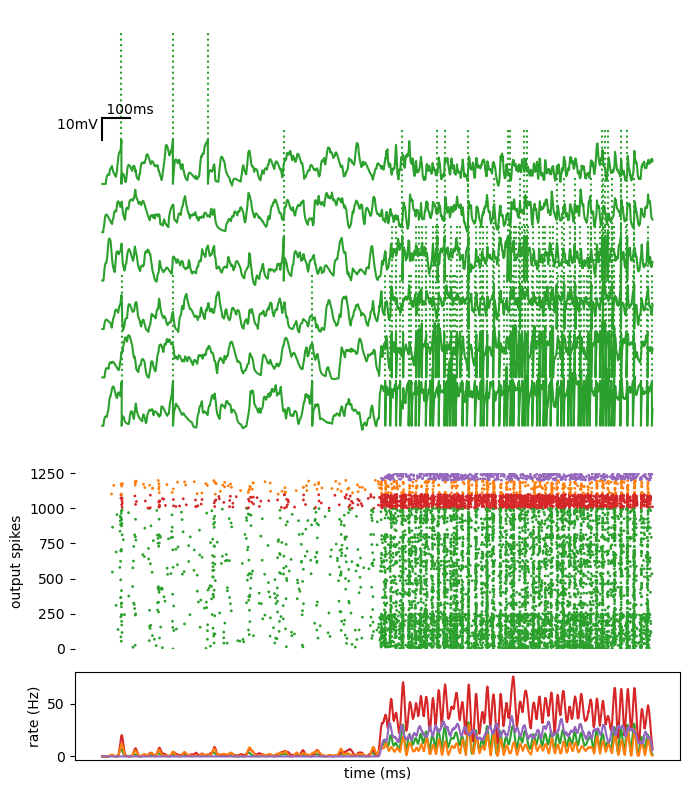

In [23]:
from plots import plot_with_spikes

def plot(mon, spikes, rates, stim):

    # --- plot: connectivity matrix, voltage traces, raster ---
    fig = plt.figure(figsize=(7, 8))
    gs = fig.add_gridspec(3, 1,
                          height_ratios=[5, 2, 1])

    ax_v = fig.add_subplot(gs[0], frameon=False)
    colors = ['C2' for i in range(6)]+['C3', 'C3']+['C1', 'C1']
    for n in range(mon.v.shape[0]):
        plot_with_spikes(ax_v, mon, n, shift=n*22,
                         color=colors[n])

    # show bar scale
    ax_v.plot([0,0], El/mV+(n+2)*20-np.arange(2)*10, 'k-')
    ax_v.plot([0,100], El/mV+(n+2)*20-np.zeros(2), 'k-')
    ax_v.annotate('10mV ', (0,El/mV+(n+2)*20), va='top', ha='right', xycoords='data')
    ax_v.annotate(' 100ms', (0,El/mV+(n+2)*20+2), xycoords='data')
    ax_v.axis('off')

    ax_r = fig.add_subplot(gs[1], sharex=ax_v, frameon=False)
    # we randomly subsample spikes if they are too numerous for display
    spike_subsampling = np.random.choice(np.arange(len(spikes.i)),
                                         np.min([10000, len(spikes.i)]),
                                         replace=False)
    def colors(n):
        if n<ntwk['N_PYR']:
            return 'C2'
        elif n>=ntwk['N_PYR']+ntwk['N_PV']+ntwk['N_SST']:
            return 'C4'
        elif n>=ntwk['N_PYR']+ntwk['N_PV']:
            return 'C1'
        else:
            return 'C3'
    ax_r.scatter(spikes.t[spike_subsampling]/ms, spikes.i[spike_subsampling],
                 c=[colors(i) for i in spikes.i[spike_subsampling]], s=1)
    ax_r.set_ylabel('output spikes')
    ax_r.set_xticks([])
    ax_r.set_ylim([-1,ntwk['N']])

    ax_f = fig.add_subplot(gs[2], sharex=ax_v)
    width = 5*ms
    for i, rate, color in zip(range(4), rates, ['C2', 'C3', 'C1', 'C4']):
        ax_f.plot(rate.t/ms, rate.smooth_rate(window='gaussian', width=width)/brian.Hz,
                    color=color)
    ax_f.set_xlabel('time (ms)'); 
    ax_f.set_ylabel('rate (Hz)')
    #ax_f.set_yscale('log') 
    #ax_f.set_yticks([0.1,1,10,100]) 

    if stim is not None:
        for ax in [ax_v, ax_r, ax_f]:
            ylim = ax.get_ylim()
            for n in range(stim['nstim']):
                ax.fill_between(stim['prestim']+n*(stim['interstim']+stim['window'])+np.arange(2)*stim['window'],
                                ylim[0]*np.ones(2), ylim[1]*np.ones(2), color='k', alpha=.2, lw=0)

    plt.tight_layout()

plot(mon, spikes, [ratePYR, ratePV, rateSST, rateVIP], stim)

In [24]:
spikes, mon, ratePYR, ratePV, rateSST, rateVIP, stim = run_sim(ntwk,
                                                               f_ext=1,
                                                               t0_neuromod=0, 
                                                               #f_neuromod=0.,
                                                               pattern_id=0)

Text(0.5, 0, 'time from stim. (ms)')

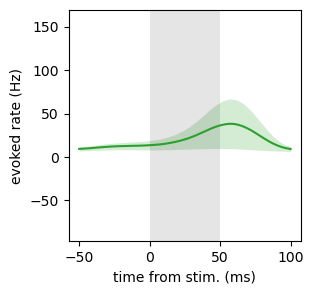

In [25]:
# evoked response
from scipy.stats import sem
fig, ax = plt.subplots(figsize=(3,3))
ax.plot(stim['t_rate'], stim['rates'].mean(axis=0), color='C2')
ax.fill_between(stim['t_rate'], 
                stim['rates'].mean(axis=0)+sem(stim['rates'],axis=0),
                stim['rates'].mean(axis=0)-sem(stim['rates'],axis=0),
                alpha=.2, lw=0, color='C2')
ylim = ax.get_ylim()
ax.set_ylim([ylim[0]-1.5*(ylim[1]-ylim[0]), ylim[1]+1.5*(ylim[1]-ylim[0])])
ylim = ax.get_ylim()
ax.fill_between([0, stim['window']], ylim[0]*np.ones(2), ylim[1]*np.ones(2), color='k', alpha=.1, lw=0)
ax.set_ylabel('evoked rate (Hz)')
ax.set_xlabel('time from stim. (ms)')

## Decoding Analysis

In [28]:
iSmooth = 5 # smoothing of the event-based spiking responses 
X, y = [], []
for pattern in range(5):
    spikes, mon, ratePYR, _, _, _, stim = run_sim(ntwk,
                                         pattern_id=pattern, 
                                         f_ext=1,
                                         t0_neuromod=0, 
                                         seed=pattern+10)
    for repeat in range(stim['response'].shape[0]):
        X.append(gaussian_filter1d(\
            stim['response'][repeat,:,:], iSmooth).flatten())
        y.append(pattern)

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.5)


In [30]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=2)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [31]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
score = accuracy_score(y_test, y_pred)
chance = 1./len(np.unique(y))
print(score)

0.8


Fold scores: [0.84 0.88]
Mean +/- SEM: 0.860 +/- 0.020


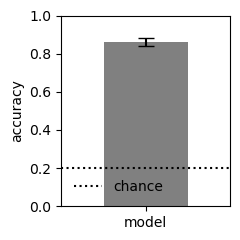

In [32]:
from sklearn.model_selection import KFold, cross_val_score
from scipy.stats import sem

cv = KFold(n_splits=2, shuffle=True, random_state=0)
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

mean_score = scores.mean()
sem_score  = sem(scores)

print(f'Fold scores: {scores}')
print(f'Mean +/- SEM: {mean_score:.3f} +/- {sem_score:.3f}')

# --- bar plot ---
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.bar(['model'], [mean_score], yerr=[sem_score], capsize=6,
       color='gray', width=0.5)
ax.plot([-0.5,.5], [chance, chance], 'k:', label='chance')
ax.set_ylabel('accuracy')
ax.set_ylim(0, 1)
ax.set_xlim([-.5, .5])
ax.legend(frameon=False)
plt.tight_layout()